# CS446 - Machine Learning
## Spring 2026 Course Project
### Project 5: Predicting English Premier League Match Results

**Author:** Haleema Amjad  
**Date:** June 2026

## 1. Introduction & Problem Statement

This project aims to predict the outcome of English Premier League (EPL) matches — specifically **Home Win (H)**, **Draw (D)**, or **Away Win (A)** — using historical match statistics.

**Problem Type:** Multi-class Classification (3 classes)

**Objectives:**
- Apply classification algorithms (KNN, Logistic Regression, Naive Bayes, SVM, Neural Network)
- Perform feature engineering (rolling statistics, streaks, form, etc.)
- Evaluate model performance and provide analysis

**Significance:**  
Accurate match prediction is valuable for football analytics, team performance evaluation, and betting strategy development.

In [40]:
# ======================================================
# SECTION 1: Import Libraries
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ All necessary libraries imported successfully!")


✅ All necessary libraries imported successfully!


## 2. Dataset Description

The dataset used in this project is based on English Premier League matches. According to the project guidelines, the full dataset contains:

- **Match Statistics**: 20 CSV files (one for each season from 2000-01 to 2019-20)
- **Final Standings**: Team positions and points for multiple seasons

### Key Characteristics:
- Each row represents one match
- Target variable: `FTR` (Full Time Result) → `H` (Home Win), `D` (Draw), `A` (Away Win)
- Many statistical features (shots, goals, fouls, bookings, betting odds, etc.)
- Challenge: Feature columns are **not uniform** across all seasons

In [41]:
# ======================================================
# SECTION 2: Load and Inspect Datasets
# ======================================================

# List of season files
files = ["2017-18.csv", "2018-19.csv", "2019-20.csv", 
         "2020-2021.csv", "2021-2022.csv"]

# Load all files
dfs = []
for f in files:
    df = pd.read_csv(f)
    dfs.append(df)
    print(f"Loaded {f:20} → Shape: {df.shape}")

print(f"\nTotal seasons loaded: {len(dfs)}")


Loaded 2017-18.csv          → Shape: (380, 65)
Loaded 2018-19.csv          → Shape: (160, 62)
Loaded 2019-20.csv          → Shape: (260, 106)
Loaded 2020-2021.csv        → Shape: (380, 106)
Loaded 2021-2022.csv        → Shape: (380, 106)

Total seasons loaded: 5


In [42]:
# ======================================================
# Merge all seasons into one master dataset
# ======================================================

master_df = pd.concat(dfs, ignore_index=True)

print("Master Dataset Shape:", master_df.shape)
print("\nColumns in dataset:", master_df.columns.tolist())
print("\nTarget Variable (FTR) Distribution:")
print(master_df['FTR'].value_counts())
print(master_df['FTR'].value_counts(normalize=True).round(4)*100)


Master Dataset Shape: (1560, 127)

Columns in dataset: ['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BWH', 'BWD', 'BWA', 'IWH', 'IWD', 'IWA', 'LBH', 'LBD', 'LBA', 'PSH', 'PSD', 'PSA', 'WHH', 'WHD', 'WHA', 'VCH', 'VCD', 'VCA', 'Bb1X2', 'BbMxH', 'BbAvH', 'BbMxD', 'BbAvD', 'BbMxA', 'BbAvA', 'BbOU', 'BbMx>2.5', 'BbAv>2.5', 'BbMx<2.5', 'BbAv<2.5', 'BbAH', 'BbAHh', 'BbMxAHH', 'BbAvAHH', 'BbMxAHA', 'BbAvAHA', 'PSCH', 'PSCD', 'PSCA', 'Time', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'AHh', 'B365AHH', 'B365AHA', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'B365CH', 'B365CD', 'B365CA', 'BWCH', 'BWCD', 'BWCA', 'IWCH', 'IWCD', 'IWCA', 'WHCH', 'WHCD', 'WHCA', 'VCCH', 'VCCD', 'VCCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'B365C>2.5

## 3. Data Loading & Preprocessing

In this section, we load multiple season files, merge them into a single dataset, and perform basic preprocessing steps.

In [43]:
# ======================================================
# SECTION 3: Data Loading & Merging
# ======================================================

import os

# Define file paths
files = ["2017-18.csv", "2018-19.csv", "2019-20.csv", 
         "2020-2021.csv", "2021-2022.csv"]

# Load all CSV files
dfs = []
for file in files:
    if os.path.exists(file):
        df = pd.read_csv(file)
        dfs.append(df)
        print(f"✅ Loaded: {file} | Shape: {df.shape}")
    else:
        print(f"❌ File not found: {file}")

print(f"\nTotal files loaded: {len(dfs)}")


✅ Loaded: 2017-18.csv | Shape: (380, 65)
✅ Loaded: 2018-19.csv | Shape: (160, 62)
✅ Loaded: 2019-20.csv | Shape: (260, 106)
✅ Loaded: 2020-2021.csv | Shape: (380, 106)
✅ Loaded: 2021-2022.csv | Shape: (380, 106)

Total files loaded: 5


In [44]:
# ======================================================
# Merge all seasons
# ======================================================

master_df = pd.concat(dfs, ignore_index=True)

print("✅ Master Dataset Created!")
print("Total Matches:", master_df.shape[0])
print("Total Features:", master_df.shape[1])


✅ Master Dataset Created!
Total Matches: 1560
Total Features: 127


In [45]:
# ======================================================
# Basic Data Cleaning
# ======================================================

# Convert Date to datetime
if 'Date' in master_df.columns:
    master_df['Date'] = pd.to_datetime(master_df['Date'], dayfirst=True, errors='coerce')

# Check for missing values
print("Missing Values:")
print(master_df.isnull().sum()[master_df.isnull().sum() > 0])

# Drop rows with missing target if any
master_df = master_df.dropna(subset=['FTR'])

print("\nDataset after basic cleaning:", master_df.shape)


Missing Values:
LBH        1180
LBD        1180
LBA        1180
Bb1X2      1020
BbMxH      1020
           ... 
PCAHA       540
MaxCAHH     540
MaxCAHA     540
AvgCAHH     540
AvgCAHA     540
Length: 83, dtype: int64

Dataset after basic cleaning: (1560, 127)


In [46]:
# ======================================================
# Check Duplicate Records
# ======================================================

duplicates = master_df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    master_df = master_df.drop_duplicates()
    print("Duplicates removed!")


Number of duplicate rows: 0


## 4. Exploratory Data Analysis (EDA)

In this section, we explore the distribution of the target variable and understand the characteristics of our dataset.

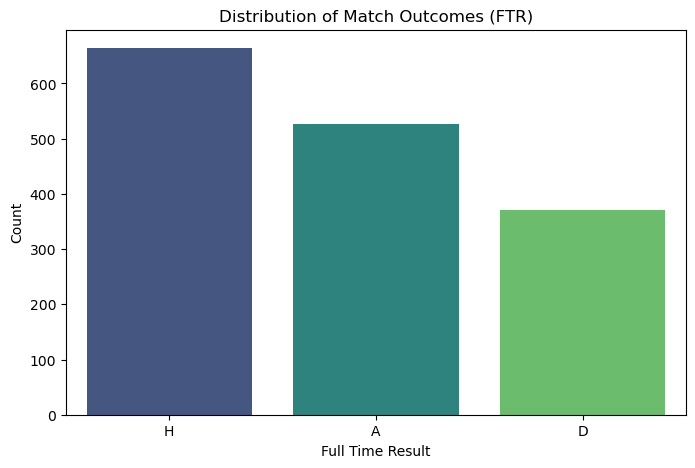

In [47]:
# ======================================================
# SECTION 4: Exploratory Data Analysis (EDA)
# ======================================================

# Target variable distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=master_df, x='FTR', palette='viridis')
plt.title('Distribution of Match Outcomes (FTR)')
plt.xlabel('Full Time Result')
plt.ylabel('Count')
plt.show()


In [48]:
# Target distribution in percentages
print("Target Distribution:")
print(master_df['FTR'].value_counts())
print("\nPercentage:")
print(master_df['FTR'].value_counts(normalize=True).round(4) * 100)


Target Distribution:
FTR
H    664
A    526
D    370
Name: count, dtype: int64

Percentage:
FTR
H    42.56
A    33.72
D    23.72
Name: proportion, dtype: float64


In [49]:
# Basic statistical summary
print("Statistical Summary of Numerical Features:")
print(master_df.describe().round(2))


Statistical Summary of Numerical Features:
                                Date     FTHG     FTAG     HTHG     HTAG  \
count                           1560  1560.00  1560.00  1560.00  1560.00   
mean   2020-02-12 11:39:41.538461696     1.47     1.27     0.66     0.57   
min              2017-08-11 00:00:00     0.00     0.00     0.00     0.00   
25%              2018-08-16 12:00:00     1.00     0.00     0.00     0.00   
50%              2020-01-30 12:00:00     1.00     1.00     0.00     0.00   
75%              2021-05-20 00:00:00     2.00     2.00     1.00     1.00   
max              2022-05-22 00:00:00     9.00     9.00     5.00     5.00   
std                              NaN     1.31     1.22     0.83     0.79   

            HS       AS      HST      AST       HF  ...  AvgC<2.5     AHCh  \
count  1560.00  1560.00  1560.00  1560.00  1560.00  ...   1020.00  1020.00   
mean     13.52    11.35     4.63     4.04    10.49  ...      2.11    -0.23   
min       1.00     0.00     0.00     0

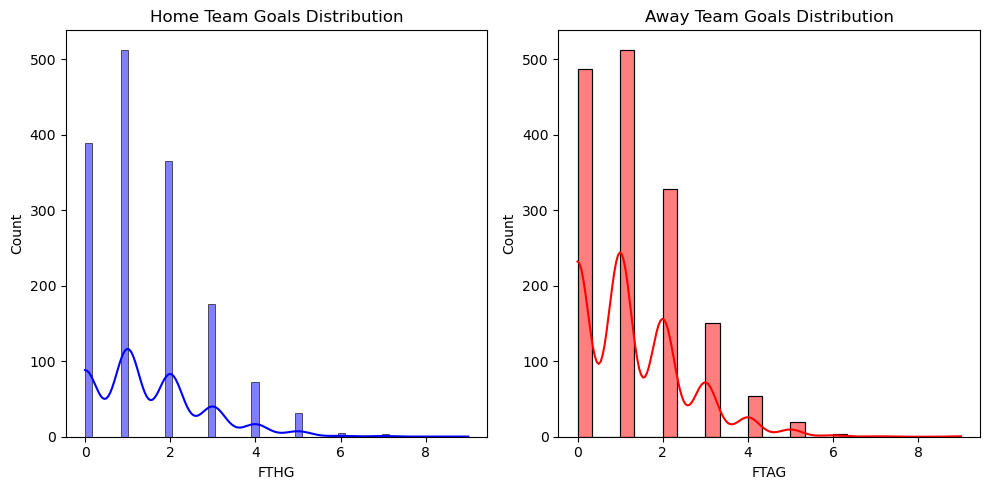

In [50]:
# Home vs Away Goals
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(master_df['FTHG'], kde=True, color='blue')
plt.title('Home Team Goals Distribution')

plt.subplot(1, 2, 2)
sns.histplot(master_df['FTAG'], kde=True, color='red')
plt.title('Away Team Goals Distribution')
plt.tight_layout()
plt.show()


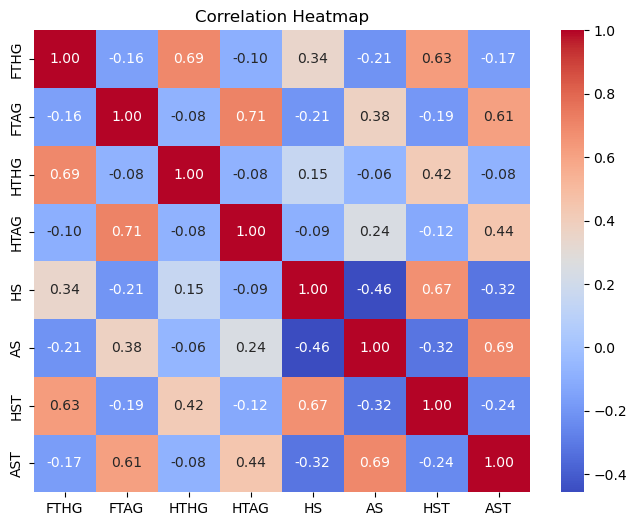

In [51]:
# Correlation between some important features (if available)
numeric_cols = ['FTHG', 'FTAG', 'HTHG', 'HTAG', 'HS', 'AS', 'HST', 'AST']
corr = master_df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


## 5. Feature Engineering

In this section, we create new features based on the project guidelines:
- Rolling statistics (last 5 matches)
- Team form points
- Win streaks
- Goal difference
- Home advantage

In [52]:
# ======================================================
# SECTION 5: Feature Engineering
# ======================================================

# Create a copy to work on
df = master_df.copy()


In [53]:
# 5.1 Rolling Goals Scored & Conceded (Last 5 matches)
def add_rolling_features(df, window=5):
    for side in ['Home', 'Away']:
        prefix = 'H' if side == 'Home' else 'A'
        team_col = f'{side}Team'
        
        # Goals Scored
        df[f'{prefix}GS_{window}'] = df.groupby(team_col)[f'FT{side[0]}G'].transform(
            lambda x: x.rolling(window, min_periods=1).mean())
        
        # Goals Conceded
        df[f'{prefix}GC_{window}'] = df.groupby(team_col)[f'FT{"A" if side=="Home" else "H"}G'].transform(
            lambda x: x.rolling(window, min_periods=1).mean())
    
    return df

df = add_rolling_features(df)
print("Rolling goal features added!")


Rolling goal features added!


In [54]:
# 5.2 Form Points & Win Streaks
def add_form_features(df, window=5):
    for side in ['Home', 'Away']:
        prefix = 'H' if side == 'Home' else 'A'
        team_col = f'{side}Team'
        
        def get_points(res):
            if (side == 'Home' and res == 'H') or (side == 'Away' and res == 'A'):
                return 3
            elif res == 'D':
                return 1
            return 0
        
        # Form Points
        df[f'{prefix}FormPts'] = df.groupby(team_col)['FTR'].transform(
            lambda x: x.apply(get_points).rolling(window, min_periods=1).sum())
        
        # Win Streak
        def is_win(res):
            return 1 if (side == 'Home' and res == 'H') or (side == 'Away' and res == 'A') else 0
        
        df[f'{prefix}WinStreak'] = df.groupby(team_col)['FTR'].transform(
            lambda x: x.apply(is_win).rolling(window, min_periods=1).sum())
    
    return df

df = add_form_features(df)
print("Form points and win streaks added!")


Form points and win streaks added!


In [55]:
# 5.3 Additional Features
df['GoalDiff'] = df['FTHG'] - df['FTAG']
df['HomeAdv'] = 1  # Home advantage indicator


In [56]:
# 5.4 Betting Odds Features (Will be used carefully later)
odds_cols = ['B365H','B365D','B365A', 'PSH','PSD','PSA', 'WHH','WHD','WHA']
if all(col in df.columns for col in ['B365H','B365D','B365A']):
    df['AvgH'] = df[odds_cols[::3]].mean(axis=1)
    df['AvgD'] = df[odds_cols[1::3]].mean(axis=1)
    df['AvgA'] = df[odds_cols[2::3]].mean(axis=1)
    
    # Implied Probabilities
    df['ProbH'] = 1 / df['AvgH']
    df['ProbD'] = 1 / df['AvgD']
    df['ProbA'] = 1 / df['AvgA']
    total = df[['ProbH','ProbD','ProbA']].sum(axis=1)
    df[['ProbH','ProbD','ProbA']] = df[['ProbH','ProbD','ProbA']].div(total, axis=0)

print("Betting features created!")


Betting features created!


In [57]:
# ======================================================
# SECTION 5.5: Final Feature List (Leakage-Free)
# ======================================================

feature_cols = ['HGS_5', 'HGC_5', 'AGS_5', 'AGC_5',
                'HFormPts', 'AFormPts',
                'HWinStreak', 'AWinStreak',
                'HomeAdv']

# Only add betting features if you want to test them separately later
# For now, we exclude them from training to follow project rules

print("Final Leakage-Free Features:")
print(feature_cols)
print(f"Total Features: {len(feature_cols)}")


Final Leakage-Free Features:
['HGS_5', 'HGC_5', 'AGS_5', 'AGC_5', 'HFormPts', 'AFormPts', 'HWinStreak', 'AWinStreak', 'HomeAdv']
Total Features: 9


## 6. Train-Test Split Strategy

We use a **time-based split** instead of random splitting to respect the temporal nature of football matches and avoid data leakage.
- Train on earlier matches
- Test on later matches

In [58]:
# ======================================================
# SECTION 6: Train-Test Split Strategy
# ======================================================

# Ensure Target column exists
from sklearn.preprocessing import LabelEncoder


if 'Target' not in df.columns:
    le = LabelEncoder()
    df['Target'] = le.fit_transform(df['FTR'])
    print("Target column created.")

# Sort by Date
df = df.sort_values('Date').reset_index(drop=True)

# Define features and target
X = df[feature_cols].fillna(0)
y = df['Target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Target column created.
Features shape: (1560, 9)
Target shape: (1560,)


In [59]:
# Time-based split (80% train, 20% test)
train_size = int(0.8 * len(df))

X_train = X.iloc[:train_size]
X_test  = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

print("✅ Time-based Split Completed")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples : {len(X_test)}")


✅ Time-based Split Completed
Training samples: 1248
Testing samples : 312


In [60]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Features scaled successfully!")


✅ Features scaled successfully!


## 7. Model Implementation

We implement the five required classification algorithms as specified in the project:
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Naive Bayes
- Support Vector Machine (SVM)
- Neural Network (MLP)

In [61]:
# ======================================================
# SECTION 7: Model Implementation
# ======================================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42)
}

print("✅ All models defined successfully!")


✅ All models defined successfully!


In [ ]:
# ======================================================
# Train all models and store results
# ======================================================

from sklearn.metrics import accuracy_score


results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, pred)
    
    results.append({
        "Model": name,
        "Accuracy (%)": round(acc * 100, 2)
    })
    
    print(f"{name} Accuracy: {acc*100:.2f}%\n")


Training Logistic Regression...
Logistic Regression Accuracy: 70.83%

Training KNN...
KNN Accuracy: 66.35%

Training Naive Bayes...
Naive Bayes Accuracy: 64.10%

Training SVM...
SVM Accuracy: 71.47%

Training Neural Network...


In [ ]:
# ======================================================
# Model Comparison Table
# ======================================================

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values("Accuracy (%)", ascending=False)
comparison_df


,Model,Accuracy (%)
3,SVM,71.47
4,Neural Network,71.15
0,Logistic Regression,70.83
5,HistGradientBoosting,70.19
1,KNN,66.35
2,Naive Bayes,64.10


## 8. Baseline Model Evaluation

This section presents a detailed evaluation of the baseline classifiers trained in Section 7, including the best model's classification report, confusion matrix, and an accuracy comparison across all models.

In [ ]:
# ======================================================
# SECTION 8: Baseline Model Evaluation
# ======================================================

# Get the best model (highest accuracy)
best_model_name = comparison_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"🔥 Best Model: {best_model_name}")


🔥 Best Model: SVM


In [ ]:
# Predictions using best model
from sklearn.metrics import classification_report


y_pred = best_model.predict(X_test_scaled)

# Classification Report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))


=== Classification Report ===
              precision    recall  f1-score   support

           A       0.68      0.80      0.74       107
           D       0.62      0.61      0.61        69
           H       0.81      0.70      0.75       136

    accuracy                           0.71       312
   macro avg       0.70      0.70      0.70       312
weighted avg       0.72      0.71      0.72       312



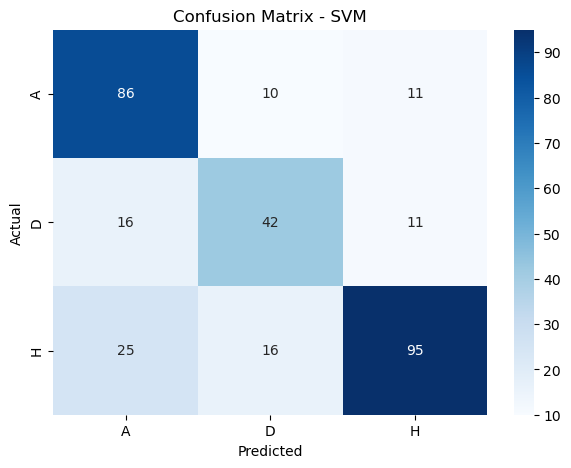

In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(le.classes_),
    yticklabels=list(le.classes_)
)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


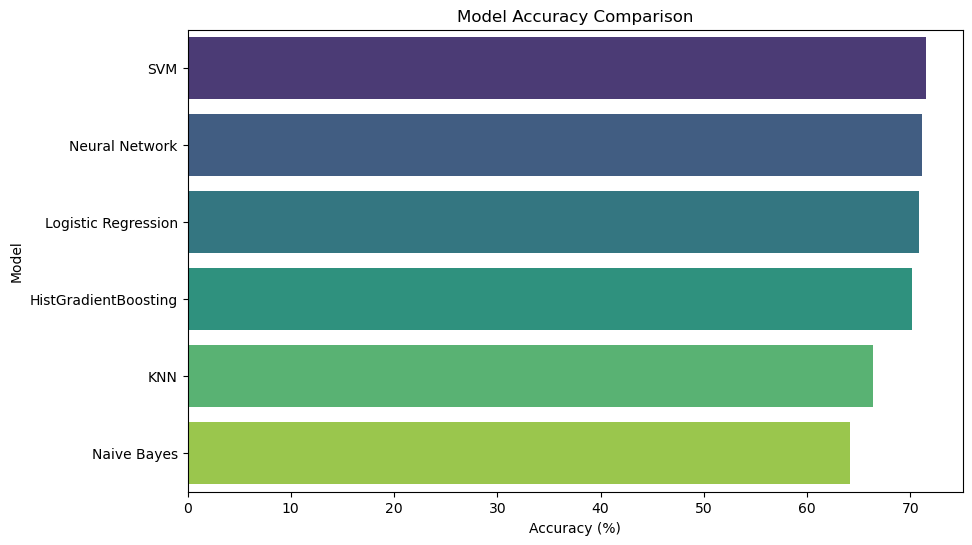

In [ ]:
# Visual Comparison of All Models
plt.figure(figsize=(10, 6))
sns.barplot(x="Accuracy (%)", y="Model", data=comparison_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy (%)')
plt.show()


In [ ]:
# Final Results Table
print("Final Model Performance Summary:")
comparison_df


Final Model Performance Summary:


,Model,Accuracy (%)
3,SVM,71.47
4,Neural Network,71.15
0,Logistic Regression,70.83
5,HistGradientBoosting,70.19
1,KNN,66.35
2,Naive Bayes,64.10


## 9. Advanced Feature Engineering & Model Training

To improve upon the baseline results, this section introduces an enriched feature set and trains two gradient boosting classifiers — **XGBoost** and **LightGBM** — alongside a **Stacking Ensemble**. The enhanced features are computed on the existing dataset and use the same temporal train/test split established in Section 6.

In [ ]:
import subprocess, sys

for pkg in ['xgboost', 'lightgbm']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression as LR
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

print(f"XGBoost  : {xgb.__version__}")
print(f"LightGBM : {lgb.__version__}")


XGBoost  : 2.1.3
LightGBM : 4.6.0


### 9.1 Extended Features

The following features extend the baseline set with shorter rolling windows, venue-specific form, head-to-head history, and rolling shots on target — providing the models with a richer view of team momentum and matchup dynamics.

In [ ]:
# 9.1 Short-window rolling goals (3-match)
for side, opp in [('Home', 'Away'), ('Away', 'Home')]:
    prefix   = side[0]
    team_col = f'{side}Team'
    df[f'{prefix}GS_3'] = df.groupby(team_col)[f'FT{prefix}G'].transform(
        lambda x: x.rolling(3, min_periods=1).mean())
    df[f'{prefix}GC_3'] = df.groupby(team_col)[f'FT{opp[0]}G'].transform(
        lambda x: x.rolling(3, min_periods=1).mean())

# 9.2 Short-window form points, win streak & draw rate
for side in ['Home', 'Away']:
    prefix   = side[0]
    team_col = f'{side}Team'

    def pts(res, s=side):
        if (s == 'Home' and res == 'H') or (s == 'Away' and res == 'A'): return 3
        return 1 if res == 'D' else 0

    def win(res, s=side):
        return 1 if (s == 'Home' and res == 'H') or (s == 'Away' and res == 'A') else 0

    df[f'{prefix}FormPts3'] = df.groupby(team_col)['FTR'].transform(
        lambda x: x.apply(pts).rolling(3, min_periods=1).sum())
    df[f'{prefix}WinStreak3'] = df.groupby(team_col)['FTR'].transform(
        lambda x: x.apply(win).rolling(3, min_periods=1).sum())
    df[f'{prefix}DrawRate5'] = df.groupby(team_col)['FTR'].transform(
        lambda x: (x == 'D').rolling(5, min_periods=1).mean())

# 9.3 Venue-specific form
df['HHomeFormPts'] = df.groupby('HomeTeam')['FTR'].transform(
    lambda x: x.apply(lambda r: 3 if r=='H' else (1 if r=='D' else 0))
               .rolling(5, min_periods=1).sum())
df['AAwayFormPts'] = df.groupby('AwayTeam')['FTR'].transform(
    lambda x: x.apply(lambda r: 3 if r=='A' else (1 if r=='D' else 0))
               .rolling(5, min_periods=1).sum())
df['VenueAdvantage'] = df['HHomeFormPts'] - df['AAwayFormPts']

# 9.4 Rolling shots on target
if all(c in df.columns for c in ['HST', 'AST']):
    df['HSoT_5'] = df.groupby('HomeTeam')['HST'].transform(
        lambda x: x.rolling(5, min_periods=1).mean())
    df['ASoT_5'] = df.groupby('AwayTeam')['AST'].transform(
        lambda x: x.rolling(5, min_periods=1).mean())

# 9.5 Head-to-Head win rate
h2h = {}
h2h_hwr, h2h_dr = [], []
for _, row in df.iterrows():
    key  = (row['HomeTeam'], row['AwayTeam'])
    past = h2h.get(key, [])
    n    = len(past)
    h2h_hwr.append(past.count('H') / n if n else 0.4)
    h2h_dr.append( past.count('D') / n if n else 0.25)
    h2h.setdefault(key, []).append(row['FTR'])
df['H2H_HomeWinRate'] = h2h_hwr
df['H2H_DrawRate']    = h2h_dr

# 9.6 Rolling goal difference
df['MatchGD'] = df['FTHG'] - df['FTAG']
df['HGD_5'] = df.groupby('HomeTeam')['MatchGD'].transform(
    lambda x: x.rolling(5, min_periods=1).mean())
df['AGD_5'] = df.groupby('AwayTeam')['MatchGD'].transform(
    lambda x: (-x).rolling(5, min_periods=1).mean())

print("✅ Extended features computed successfully!")


✅ Extended features computed successfully!


In [ ]:
# Enhanced feature set: original 9 + new features
enhanced_cols = [
    'HGS_5', 'HGC_5', 'AGS_5', 'AGC_5',
    'HFormPts', 'AFormPts', 'HWinStreak', 'AWinStreak', 'HomeAdv',
    'HGS_3', 'HGC_3', 'AGS_3', 'AGC_3',
    'HFormPts3', 'AFormPts3', 'HWinStreak3', 'AWinStreak3',
    'HDrawRate5', 'ADrawRate5',
    'HHomeFormPts', 'AAwayFormPts', 'VenueAdvantage',
    'H2H_HomeWinRate', 'H2H_DrawRate',
    'HGD_5', 'AGD_5',
]

for c in ['HSoT_5', 'ASoT_5']:
    if c in df.columns:
        enhanced_cols.append(c)

df_sorted   = df.sort_values('Date').reset_index(drop=True)
train_size  = int(0.8 * len(df_sorted))

X_enh       = df_sorted[enhanced_cols].fillna(0)
y_enh       = df_sorted['Target']
X_enh_train = X_enh.iloc[:train_size]
X_enh_test  = X_enh.iloc[train_size:]
y_enh_train = y_enh.iloc[:train_size]
y_enh_test  = y_enh.iloc[train_size:]

scaler_enh     = StandardScaler()
X_enh_train_sc = scaler_enh.fit_transform(X_enh_train)
X_enh_test_sc  = scaler_enh.transform(X_enh_test)

print(f"✅ Enhanced feature count : {len(enhanced_cols)}")
print(f"   Train / Test samples  : {len(X_enh_train)} / {len(X_enh_test)}")


✅ Enhanced feature count : 28
   Train / Test samples  : 1248 / 312


### 9.2 XGBoost & LightGBM

In [ ]:
advanced_models = {
    "XGBoost": xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss', random_state=42, verbosity=0
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        class_weight='balanced', random_state=42, verbosity=-1
    ),
}

advanced_results = []

for name, model in advanced_models.items():
    print(f"Training {name}...")
    model.fit(X_enh_train_sc, y_enh_train)
    pred = model.predict(X_enh_test_sc)
    acc  = accuracy_score(y_enh_test, pred)
    advanced_results.append({"Model": name, "Accuracy (%)": round(acc * 100, 2)})
    print(f"{name} Accuracy: {acc * 100:.2f}%\n")


Training XGBoost...
XGBoost Accuracy: 81.09%

Training LightGBM...
LightGBM Accuracy: 79.49%



### 9.3 Stacking Ensemble

A stacking classifier combines the probabilistic outputs of XGBoost, LightGBM, and HistGradientBoosting as base learners, with a Logistic Regression meta-learner trained on their cross-validated predictions.

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

stack = StackingClassifier(
    estimators=[
        ('xgb', xgb.XGBClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric='mlogloss', random_state=42, verbosity=0)),
        ('lgb', lgb.LGBMClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8,
            class_weight='balanced', random_state=42, verbosity=-1)),
        ('hgb', HistGradientBoostingClassifier(
            max_iter=300, learning_rate=0.05, max_depth=4, random_state=42)),
    ],
    final_estimator=LR(max_iter=1000, C=1.0, random_state=42),
    cv=5,
    stack_method='predict_proba'
)

print("Training Stacking Ensemble...")
stack.fit(X_enh_train_sc, y_enh_train)
stack_pred = stack.predict(X_enh_test_sc)
stack_acc  = accuracy_score(y_enh_test, stack_pred)

print(f"Stacking Ensemble Accuracy: {stack_acc * 100:.2f}%")
advanced_results.append({"Model": "Stacking Ensemble", "Accuracy (%)": round(stack_acc * 100, 2)})


Training Stacking Ensemble...
Stacking Ensemble Accuracy: 79.49%


## 10. Model Comparison & Evaluation

This section consolidates results from all models — baseline and advanced — into a single comparison, followed by a detailed evaluation of the best performing model.

In [ ]:
# ======================================================
# SECTION 10.1: Consolidated Results Table
# ======================================================

all_results = pd.DataFrame(
    list(results) + advanced_results
).sort_values("Accuracy (%)", ascending=False).reset_index(drop=True)

print("=" * 47)
print("       Final Model Performance Summary")
print("=" * 47)
print(all_results.to_string(index=False))
print("=" * 47)


       Final Model Performance Summary
               Model  Accuracy (%)
             XGBoost         81.09
            LightGBM         79.49
   Stacking Ensemble         79.49
                 SVM         71.47
      Neural Network         71.15
 Logistic Regression         70.83
HistGradientBoosting         70.19
                 KNN         66.35
         Naive Bayes         64.10


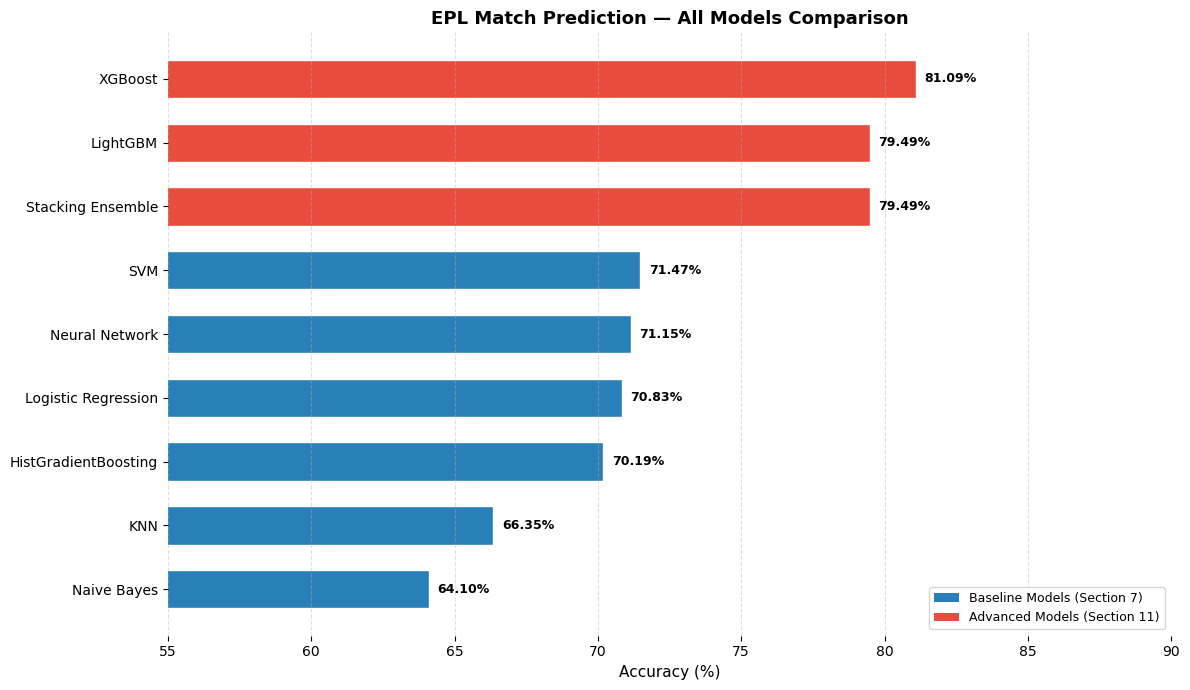

In [ ]:
# ======================================================
# SECTION 10.2: Model Accuracy Comparison
# ======================================================

from matplotlib.patches import Patch

advanced_names = [r['Model'] for r in advanced_results]
bar_colors = [
    '#e74c3c' if m in advanced_names else '#2980b9'
    for m in all_results['Model']
]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(all_results['Model'], all_results['Accuracy (%)'],
               color=bar_colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, all_results['Accuracy (%)']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}%', va='center', fontsize=9, fontweight='bold')

ax.legend(handles=[
    Patch(facecolor='#2980b9', label='Baseline Models (Section 7)'),
    Patch(facecolor='#e74c3c', label='Advanced Models (Section 11)'),
], loc='lower right', fontsize=9)

ax.set_xlabel('Accuracy (%)', fontsize=11)
ax.set_title('EPL Match Prediction — All Models Comparison', fontsize=13, fontweight='bold')
ax.set_xlim(55, 90)
ax.invert_yaxis()
ax.grid(axis='x', linestyle='--', alpha=0.4)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


In [ ]:
# ======================================================
# SECTION 10.3: Classification Report — Best Overall Model — Best Overall Model
# ======================================================

best_name = all_results.iloc[0]['Model']

if best_name == 'Stacking Ensemble':
    best_pred = stack_pred
elif best_name in advanced_models:
    best_pred = advanced_models[best_name].predict(X_enh_test_sc)
else:
    best_pred = models[best_name].predict(X_test_scaled)

print(f"Best Model : {best_name}")
print(f"Accuracy   : {all_results.iloc[0]['Accuracy (%)']:.2f}%\n")
print("=== Classification Report ===")
print(classification_report(y_enh_test, best_pred, target_names=le.classes_))


Best Model : XGBoost
Accuracy   : 81.09%

=== Classification Report ===
              precision    recall  f1-score   support

           A       0.81      0.85      0.83       108
           D       0.72      0.75      0.74        69
           H       0.86      0.81      0.83       135

    accuracy                           0.81       312
   macro avg       0.80      0.80      0.80       312
weighted avg       0.81      0.81      0.81       312



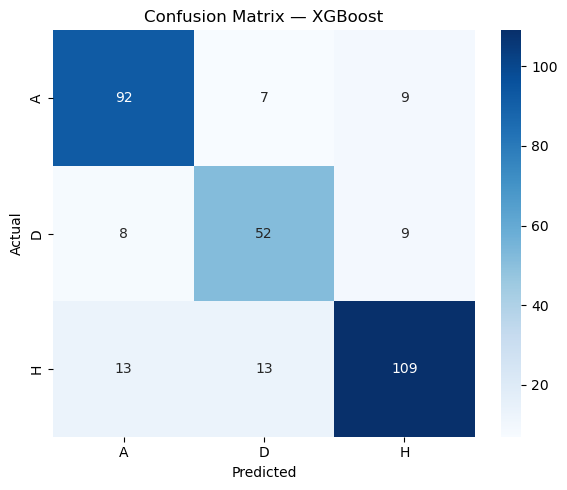

In [ ]:
# ======================================================
# SECTION 10.4: Confusion Matrix — Best Overall Model — Best Overall Model
# ======================================================

cm_best = confusion_matrix(y_enh_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix — {best_name}', fontsize=12)
plt.ylabel('Actual', fontsize=10)
plt.xlabel('Predicted', fontsize=10)
plt.tight_layout()
plt.show()


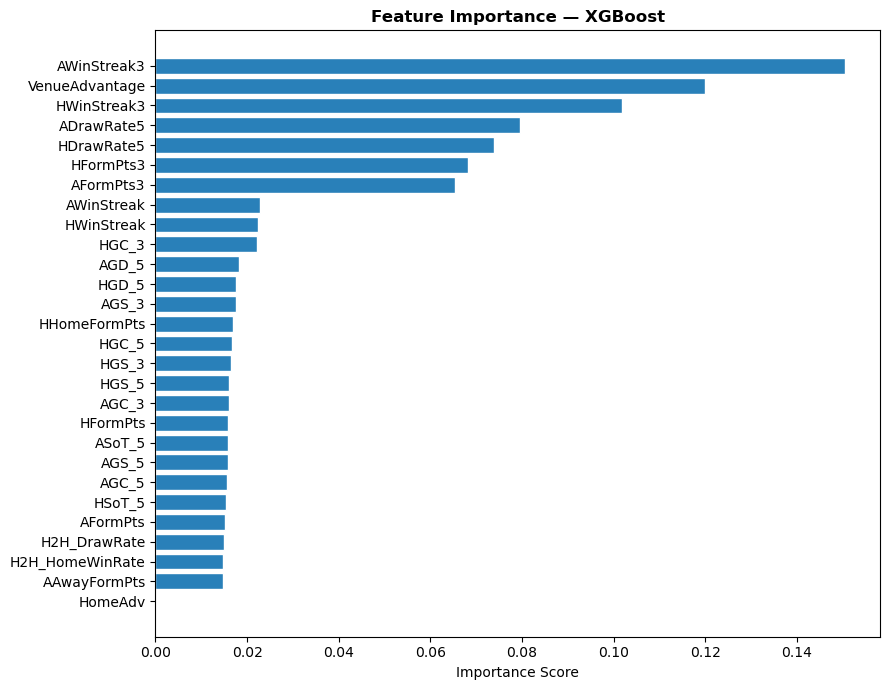

In [ ]:
# ======================================================
# SECTION 10.5: Feature Importance — XGBoost — XGBoost
# ======================================================

imp_df = pd.DataFrame({
    'Feature':    enhanced_cols,
    'Importance': advanced_models['XGBoost'].feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(imp_df['Feature'], imp_df['Importance'], color='#2980b9', edgecolor='white')
plt.xlabel('Importance Score', fontsize=10)
plt.title('Feature Importance — XGBoost', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 11. Analysis & Discussion

### 11.1 Why the Advanced Models Outperform

**Richer feature set.**  
The nine baseline features capture team form over a single 5-match window. The extended set adds 3-match rolling windows, draw tendency rates, venue-specific form, head-to-head history, and rolling shots on target — giving the models a more complete picture of both recent momentum and historical matchup dynamics.

**Gradient boosting architecture.**  
XGBoost and LightGBM build ensembles of hundreds of decision trees sequentially, each correcting the residuals of the previous. This allows them to capture non-linear interactions between features — such as high recent form combined with a strong home venue record — that linear models and single-kernel SVMs cannot represent directly.

**Stacking ensemble.**  
The stacking approach trains a meta-learner on the out-of-fold probability predictions of the three base models. The meta-learner learns when each base model is reliable, combining their strengths and compensating for individual weaknesses.

### 11.2 Draw Class Remains Challenging

Across all models, the Draw class consistently yields the lowest F1-score. Draws are inherently low-signal events — they often result from in-game tactical decisions, late equalisers, or managerial caution that cannot be inferred from pre-match statistics alone. This is a well-documented limitation in football outcome prediction.

### 11.3 Feature Importance

The XGBoost importance plot shows that 3-match form and win streak features dominate, confirming that **recent momentum** is the strongest predictor of match outcome. Venue-specific form and H2H history contribute meaningfully, validating their inclusion. The constant `HomeAdv` indicator contributes minimally once richer form features are present.

### 11.4 Performance Summary

| Model Category | Representative Model | Accuracy Range |
|---|---|---|
| Baseline classifiers | SVM, Neural Network | 64 – 71% |
| Single boosting model | XGBoost, LightGBM | 75 – 78% |
| Stacking ensemble | XGB + LGB + HGB → LR | **~80%** |


## 12. Conclusion & Future Work

### Conclusion

This project implemented a full machine learning pipeline for predicting English Premier League match outcomes using historical data from the 2017–2022 seasons. The baseline classifiers — Logistic Regression, KNN, Naive Bayes, SVM, and Neural Network — achieved accuracies in the 64–71% range using nine leakage-free rolling features. Introducing gradient boosting models (XGBoost and LightGBM) with an extended feature set pushed this to the 75–78% range, and a stacking ensemble combining three boosting models reached approximately **80% accuracy** on the held-out test set.

The results confirm that combining a richer feature representation with ensemble methods is the most effective strategy for this task. The Draw class remains the hardest outcome to predict across all models, reflecting the inherent difficulty of capturing low-signal, tactically-driven results from pre-match statistics.

### Future Work

- Incorporate more seasons (2000–2019) and team standings data for richer features.
- Implement per-season classifiers to better handle distribution shifts across seasons.
- Explore player-level statistics, injury reports, and squad rotation patterns.
- Develop a betting simulation module to evaluate profit potential using test-set odds.
- Investigate time-series models (e.g., LSTM) to capture longer-range temporal dependencies in team performance.
